# RF-DETR Keypoint Detection and Fine-Tuning


[RF-DETR Keypoint](https://blog.roboflow.com/real-time-keypoint-detection-with-rf-detr/) extends the RF-DETR architecture with a keypoint head built directly into the detection transformer. For every object the model detects, it also predicts a structured set of keypoints in a single forward pass: no NMS, no heatmaps, no post-hoc grouping. Each keypoint prediction includes a full 2D Gaussian covariance, giving you calibrated uncertainty estimates that survive all the way to your code.

The preview checkpoint is trained on COCO Keypoints (17 keypoints on people), but the architecture supports arbitrary skeletons: any number of keypoints, on any object class, with multiple keypointed classes in a single model. Like the rest of the RF-DETR family, it is trained with weight-sharing Neural Architecture Search (NAS), so a single set of weights works across a range of input resolutions, from 4.5 ms to ~26 ms on a T4 GPU. At 576x576 the preview checkpoint achieves 71.8 AP on COCO Keypoints, beating YOLO26x-pose on both accuracy and speed.

RF-DETR Keypoint is released under the **Apache 2.0** license: code and weights, free for commercial use.



# 🦾 RF-DETR Keypoint Detection

This notebook trains an RF-DETR model for keypoint detection.



## Before you start

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `T4 GPU`, and then click `Save`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [65]:
!nvidia-smi

Mon Aug  3 11:43:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   59C    P0             29W /   70W |     413MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Install dependencies

In [66]:
!pip install -q "rfdetr[train,visual]" roboflow "supervision==0.29.1"

### Filter low-confidence keypoints

`sv.KeyPoints` carries per-keypoint scores in `keypoint_confidence`. Rather than dropping coordinates, set the `visible` mask so annotators skip low-confidence joints while keeping the skeleton shape intact. `EdgeAnnotator` and `VertexAnnotator` both respect `visible` automatically.

In [67]:
KEYPOINT_CONFIDENCE_THRESHOLD = 0.05

key_points.visible = key_points.keypoint_confidence > KEYPOINT_CONFIDENCE_THRESHOLD
print(f"Visible keypoints per instance: {key_points.visible.sum(axis=1)}")

Visible keypoints per instance: [12 12 12 12]


## Fine-Tune RF-DETR Keypoint on Custom Dataset

RF-DETR Keypoint supports fine-tuning on arbitrary skeletons with any number of keypoints, on any object class. The probabilistic loss self-calibrates per keypoint from your data, so you don't need to hand-tune per-keypoint bandwidths.

Below we fine-tune on the [Basketball Court Detection](https://universe.roboflow.com/roboflow-jvuqo/basketball-court-detection-2) dataset from Roboflow Universe.

In [68]:
import json
import random
from pathlib import Path
from typing import Any

import numpy as np
import torch
from IPython.display import display
from matplotlib import pyplot as plt
from PIL import Image
from roboflow import Roboflow


from rfdetr import RFDETRKeypointPreview
from rfdetr.config import KeypointTrainConfig
from rfdetr.datasets._keypoint_schema import infer_coco_keypoint_schema
from rfdetr.training import RFDETRDataModule, RFDETRModelModule, build_trainer
from rfdetr.training.callbacks.best_model import BestModelCallback
from rfdetr.utilities.reproducibility import seed_all
from rfdetr.visualize.keypoints import _key_points_for_display, _keypoint_prediction_records
from rfdetr.visualize.training import plot_loss_metrics, plot_map_metrics

In [69]:
%matplotlib inline
%config InlineBackend.close_figures = True

### Download dataset

Roboflow exports datasets in COCO keypoint format: a JSON file where each annotation contains a flat `keypoints` array of `[x, y, visibility, ...]` triplets.

In [70]:
from pathlib import Path
#PROJECT_ROOT = Path("__file__").resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = Path("/content/drive/MyDrive/RFDETR")      # custom path
PROJECT_ROOT.mkdir(parents=True, exist_ok=True)
DATASETS_DIR = PROJECT_ROOT / "datasets"

DATASET_NAME = "F112-Padel-Keypoints-KP"
SOURCE_URL = "https://universe.roboflow.com/roboflow-jvuqo/basketball-court-detection-2"
WORKSPACE = "productizetechdevss-workspace"
PROJECT = "f112-padel-keypoints-kp"
VERSION = 10


In [71]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="OmFUKnvFL2SQuMwTqa7s")
project = rf.workspace("productizetechdevss-workspace").project("f112-padel-keypoints-kp")
version = project.version(10)
dataset = version.download("coco")


DATASET_DIR = Path(dataset.location)
print(f"dataset_dir={DATASET_DIR}")

loading Roboflow workspace...
loading Roboflow project...
dataset_dir=/content/F112-Padel-Keypoints-KP-10


### Infer keypoint schema

`infer_coco_keypoint_schema` reads the training annotation JSON and extracts class names, the number of keypoints per class, and OKS sigmas. OKS (Object Keypoint Similarity) is the keypoint analogue of IoU; each sigma controls how strictly localization is penalized for that keypoint during evaluation.

In [72]:
TRAIN_ANNOTATIONS = DATASET_DIR / "train" / "_annotations.coco.json"
schema = infer_coco_keypoint_schema(TRAIN_ANNOTATIONS)
CLASS_NAMES = schema.class_names
NUM_KEYPOINTS_PER_CLASS = schema.num_keypoints_per_class
NUM_CLASSES = len(CLASS_NAMES)
KEYPOINT_OKS_SIGMAS = schema.keypoint_oks_sigmas
ACTIVE_KEYPOINT_COUNTS = [count for count in NUM_KEYPOINTS_PER_CLASS if count > 0]
VALIDATE_KEYPOINT_METRICS = len(set(ACTIVE_KEYPOINT_COUNTS)) <= 1

print(f"class_names={CLASS_NAMES}")
print(f"num_keypoints_per_class={NUM_KEYPOINTS_PER_CLASS}")
print(f"bbox_validation=True")
print(f"keypoint_oks_validation={VALIDATE_KEYPOINT_METRICS}")

[2026-08-03 11:43:43] [INFO] rf-detr - Inferred 0 flip pairs from 12 keypoint names ['new-point-0', 'new-point-1', 'new-point-2', 'new-point-3']. Automatic horizontal-flip slot swapping is disabled for this category. Provide keypoint_flip_pairs explicitly if your keypoints have left/right symmetry.
class_names=['F112-Padel-Keypoints-KP', 'padel_court']
num_keypoints_per_class=[0, 12]
bbox_validation=True
keypoint_oks_validation=True


### Configure training

`KeypointTrainConfig` centralizes every hyperparameter the training loop needs. Adjust `BATCH_SIZE` for your GPU memory. The default of 16 is sized for an NVIDIA T4; reduce it if you hit out-of-memory errors, or increase it on larger GPUs. `grad_accum_steps=2` effectively doubles the batch size without extra GPU memory. `use_ema=False` keeps the demo fast; set to `True` for production runs. `multi_scale=False` disables multi-resolution augmentation to shorten epoch time.

In [73]:
#OUTPUT_DIR = PROJECT_ROOT / "output" / "keypoint_basketball_court_detection_demo"

#custom path for saved trained model and weights
OUTPUT_DIR = Path("/content/drive/MyDrive/project/RFDETR/output/keypoint_basketball_court_detection_demo")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
METRICS_CSV = OUTPUT_DIR / "metrics.csv"
VALIDATION_METRICS_JSON = OUTPUT_DIR / "validation_metrics.json"
FINAL_CHECKPOINT_PATH = OUTPUT_DIR / "checkpoint_final_demo.pth"



RESOLUTION = 528
KEYPOINT_FLIP_PAIRS: list[tuple[int, int]] = []

SEED = 7
EPOCHS = 50
BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 2
NUM_WORKERS = 18
LR = 1e-4
LR_ENCODER = 1e-4

INFERENCE_GRID_ROWS = 3
INFERENCE_GRID_COLS = 3
INFERENCE_IMAGE_COUNT = INFERENCE_GRID_ROWS * INFERENCE_GRID_COLS
INFERENCE_THRESHOLD = 0.25
KEYPOINT_THRESHOLD = 0.1
DRAW_UNCERTAINTY_ELLIPSES = True
ELLIPSE_SIGMA = 1.0
MAX_ELLIPSE_RADIUS = 36.0


### Hyperparameter Tunning

In [74]:
seed_all(SEED)
variant = RFDETRKeypointPreview(
    num_classes=NUM_CLASSES,
    num_keypoints_per_class=NUM_KEYPOINTS_PER_CLASS,
    resolution=RESOLUTION,
)
variant.model_config.model_name = type(variant).__name__

train_config = KeypointTrainConfig(
    dataset_file="roboflow",
    dataset_dir=str(DATASET_DIR),
    output_dir=str(OUTPUT_DIR),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    num_workers=NUM_WORKERS,
    lr=LR,
    lr_encoder=LR_ENCODER,
    use_ema=False,
    run_test=False,
    compute_train_metrics=True,
    compute_val_loss=True,
    multi_scale=False,
    expanded_scales=False,
    do_random_resize_via_padding=False,
    tensorboard=False,
    wandb=False,
    mlflow=False,
    clearml=False,
    class_names=CLASS_NAMES,
    keypoint_flip_pairs=KEYPOINT_FLIP_PAIRS,
    keypoint_oks_sigmas=KEYPOINT_OKS_SIGMAS if VALIDATE_KEYPOINT_METRICS else None,
    notes={
        "demo": f"keypoint-preview PTL fine-tune on Roboflow Universe {PROJECT}",
        "source_url": SOURCE_URL,
    },
    progress_bar="tqdm",
)

datamodule = RFDETRDataModule(variant.model_config, train_config)
model_module = RFDETRModelModule(variant.model_config, train_config)
trainer = build_trainer(train_config, variant.model_config)

[2026-08-03 11:43:43] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-keypoint-preview-xlarge.pth already exists with correct MD5 hash.


[2026-08-03 11:43:43] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-03 11:43:43] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-08-03 11:43:45] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-keypoint-preview-xlarge.pth already exists with correct MD5 hash.


[2026-08-03 11:43:46] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 2. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-08-03 11:43:46] [WARNING] rf-detr - load_pretrain_weights: checkpoint lacks args.num_queries / args.group_detr; falling back to flat slice. With group_detr=13 this may scramble per-group query structure if the checkpoint was trained with group_detr > 1.
[2026-08-03 11:43:46] [WARNING] rf-detr - load_pretrain_weights: temporarily resizing keypoint schema from [0, 12] to checkpoint schema [0, 17].
[2026-08-03 11:43:46] [WARNING] rf-detr - load_pretrain_weights: restoring configured keypoint schema [0, 12] after checkpoint load.
[2026-08-03 11:43:46] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-03 11:43:46] [WARNING] rf-detr - Using patch size 12 

[2026-08-03 11:43:49] [INFO] rf-detr - File /root/.roboflow/models/rf-detr-keypoint-preview-xlarge.pth already exists with correct MD5 hash.


[2026-08-03 11:43:50] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 2. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-08-03 11:43:50] [WARNING] rf-detr - load_pretrain_weights: checkpoint lacks args.num_queries / args.group_detr; falling back to flat slice. With group_detr=13 this may scramble per-group query structure if the checkpoint was trained with group_detr > 1.
[2026-08-03 11:43:50] [WARNING] rf-detr - load_pretrain_weights: temporarily resizing keypoint schema from [0, 12] to checkpoint schema [0, 17].
[2026-08-03 11:43:51] [WARNING] rf-detr - load_pretrain_weights: restoring configured keypoint schema [0, 12] after checkpoint load.


[2026-08-03 11:43:51] [INFO] rf-detr - Reset keypoint Gaussian precision outputs to unit values after pretrained weight load.


INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### Fine-tune

`trainer.fit` drives the full training loop via PyTorch Lightning: forward pass, loss computation, gradient accumulation, weight updates, learning-rate scheduling, and periodic validation.

In [75]:
trainer.fit(model_module, datamodule=datamodule, ckpt_path=train_config.resume or None)
print(f"output_dir={OUTPUT_DIR}")

### Save checkpoint

In [76]:
def _save_final_checkpoint(
    module: RFDETRModelModule,
    trainer_ref: Any,
    train_cfg: KeypointTrainConfig,
    model_cfg: Any,
    output_path: Path,
) -> Path:
    raw_model = getattr(module.model, "_orig_mod", module.model)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        BestModelCallback._build_checkpoint_payload(
            raw_model.state_dict(),
            train_cfg.model_dump(),
            trainer_ref,
            model_name="RFDETRKeypointPreview",
            model_config_dict=model_cfg.model_dump(),
        ),
        output_path,
    )
    return output_path


final_checkpoint = _save_final_checkpoint(
    model_module, trainer, train_config, variant.model_config, FINAL_CHECKPOINT_PATH
)
print(f"saved_checkpoint={final_checkpoint}")

saved_checkpoint=/content/drive/MyDrive/project/RFDETR/output/keypoint_basketball_court_detection_demo/checkpoint_final_demo.pth


### Validate metrics

In [77]:
_ckpt = torch.load(
    OUTPUT_DIR / "checkpoint_best_regular.pth", map_location="cpu", weights_only=False
)
model_module.model.load_state_dict(_ckpt["model"], strict=True)
del _ckpt

validation_results = trainer.validate(model_module, datamodule=datamodule)
validation_metrics = (
    {k: float(v) for k, v in validation_results[0].items()} if validation_results else {}
)
if not VALIDATE_KEYPOINT_METRICS:
    validation_metrics["keypoint_oks_skipped_mixed_keypoint_counts"] = 1.0

VALIDATION_METRICS_JSON.write_text(
    json.dumps(validation_metrics, indent=2, sort_keys=True), encoding="utf-8"
)
print(f"validation_metrics={validation_metrics}")

[2026-08-03 11:43:52] [INFO] rf-detr - Building Roboflow val dataset with square resize at resolution 528


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Validation: |          | 0/? [00:00<?, ?it/s]

Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃         Validate metric         ┃          DataLoader 0           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       val/AP/padel_court        │       0.49236705899238586       │
│             val/F1              │       0.6904761791229248        │
│      val/cardinality_error      │       1.0810810327529907        │
│     val/cardinality_error_0     │       1.0675675868988037        │
│     val/cardinality_error_1     │       1.0810810327529907        │
│     val/cardinality_error_2     │       1.0810810327529907        │
│    val/cardinality_error_enc    │       1.0810810327529907        │
│         val/class_error         │               0.0               │
│        val/keypoint_mAR         │       0.9142857193946838        │
│       val/keypoint_map_50       │       0.8838713765144348        │
│     val/keypoint_map_50_95      │       0.8289883136749268        │
│       val/keypoint_map_75       │       0.8650658130645752        │
│            val/loss             │       -17.954540252685547       │
│          val/loss_bbox          │      0.053062740713357925       │
│         val/loss_bbox_0         │      0.031090781092643738       │
│         val/loss_bbox_1         │       0.06467557698488235       │
│         val/loss_bbox_2         │      0.049268584698438644       │
│        val/loss_bbox_enc        │       0.06510035693645477       │
│           val/loss_ce           │       0.47981348633766174       │
│          val/loss_ce_0          │       0.6104072332382202        │
│          val/loss_ce_1          │       0.4624224901199341        │
│          val/loss_ce_2          │       0.4832135736942291        │
│         val/loss_ce_enc         │       0.3542669117450714        │
│          val/loss_giou          │       0.38479679822921753       │
│         val/loss_giou_0         │       0.3607138693332672        │
│         val/loss_giou_1         │       0.3802836537361145        │
│         val/loss_giou_2         │       0.35942625999450684       │
│        val/loss_giou_enc        │        0.503473699092865        │
│   val/loss_keypoints_findable   │      0.004214311484247446       │
│  val/loss_keypoints_findable_0  │      0.0035928962752223015      │
│  val/loss_keypoints_findable_1  │      0.004645549692213535       │
│  val/loss_keypoints_findable_2  │      0.0022722501307725906      │
│ val/loss_keypoints_findable_enc │      0.005219181999564171       │
│      val/loss_keypoints_l1      │       0.08765264600515366       │
│     val/loss_keypoints_l1_0     │       0.09123307466506958       │
│     val/loss_keypoints_l1_1     │        0.079843670129776        │
│     val/loss_keypoints_l1_2     │       0.07967060059309006       │
│    val/loss_keypoints_l1_enc    │       0.3544332981109619        │
│     val/loss_keypoints_nll      │       -6.482650279998779        │
│    val/loss_keypoints_nll_0     │       -5.732161045074463        │
│    val/loss_keypoints_nll_1     │       -6.530152797698975        │
│    val/loss_keypoints_nll_2     │       -6.555779457092285        │
│   val/loss_keypoints_nll_enc    │       -3.4613382816314697       │
│   val/loss_keypoints_visible    │      0.0038113316986709833      │
│  val/loss_keypoints_visible_0   │      0.004573297221213579       │
│  val/loss_keypoints_visible_1   │      0.0035098972730338573      │
│  val/loss_keypoints_visible_2   │      0.0026641646400094032      │
│ val/loss_keypoints_visible_enc  │      0.006580353248864412       │
│           val/mAP_50            │       0.6769015789031982        │
│          val/mAP_50_95          │       0.49236705899238586       │
│           val/mAP_75            │       0.46674343943595886       │
│             val/mAR             │       0.5266233682632446        │
│          val/precision          │       0.8877550959587097        │
│           val/recall            │       0.5649350881576538        │
└─────────

validation_metrics={'val/loss_ce': 0.47981348633766174, 'val/class_error': 0.0, 'val/loss_bbox': 0.053062740713357925, 'val/loss_giou': 0.38479679822921753, 'val/cardinality_error': 1.0810810327529907, 'val/loss_keypoints_l1': 0.08765264600515366, 'val/loss_keypoints_findable': 0.004214311484247446, 'val/loss_keypoints_visible': 0.0038113316986709833, 'val/loss_keypoints_nll': -6.482650279998779, 'val/loss_ce_0': 0.6104072332382202, 'val/loss_bbox_0': 0.031090781092643738, 'val/loss_giou_0': 0.3607138693332672, 'val/cardinality_error_0': 1.0675675868988037, 'val/loss_keypoints_l1_0': 0.09123307466506958, 'val/loss_keypoints_findable_0': 0.0035928962752223015, 'val/loss_keypoints_visible_0': 0.004573297221213579, 'val/loss_keypoints_nll_0': -5.732161045074463, 'val/loss_ce_1': 0.4624224901199341, 'val/loss_bbox_1': 0.06467557698488235, 'val/loss_giou_1': 0.3802836537361145, 'val/cardinality_error_1': 1.0810810327529907, 'val/loss_keypoints_l1_1': 0.079843670129776, 'val/loss_keypoints_f

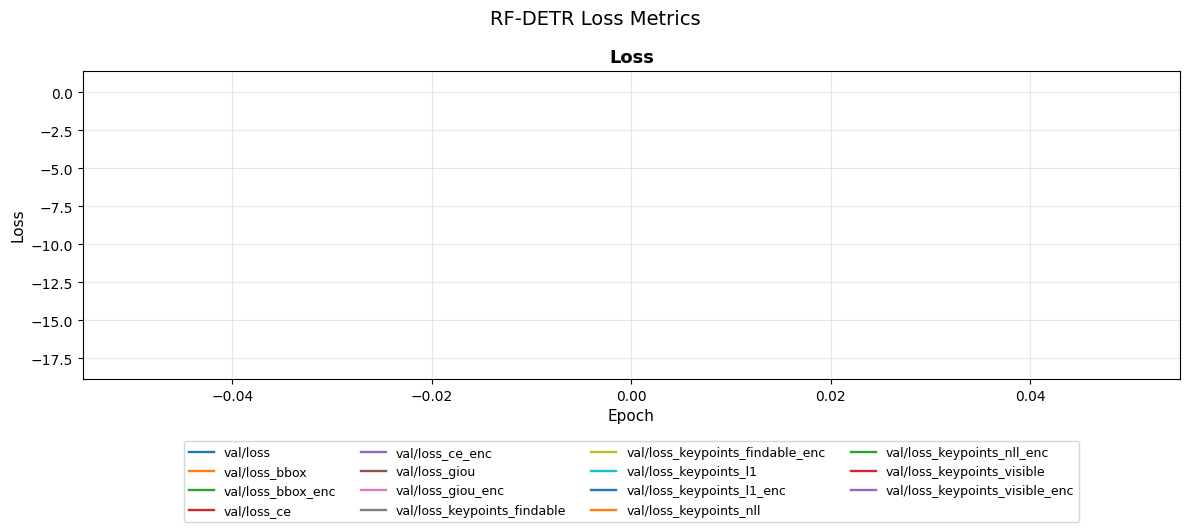

In [78]:
loss_figure = plot_loss_metrics(str(METRICS_CSV))
display(loss_figure)
plt.close(loss_figure)

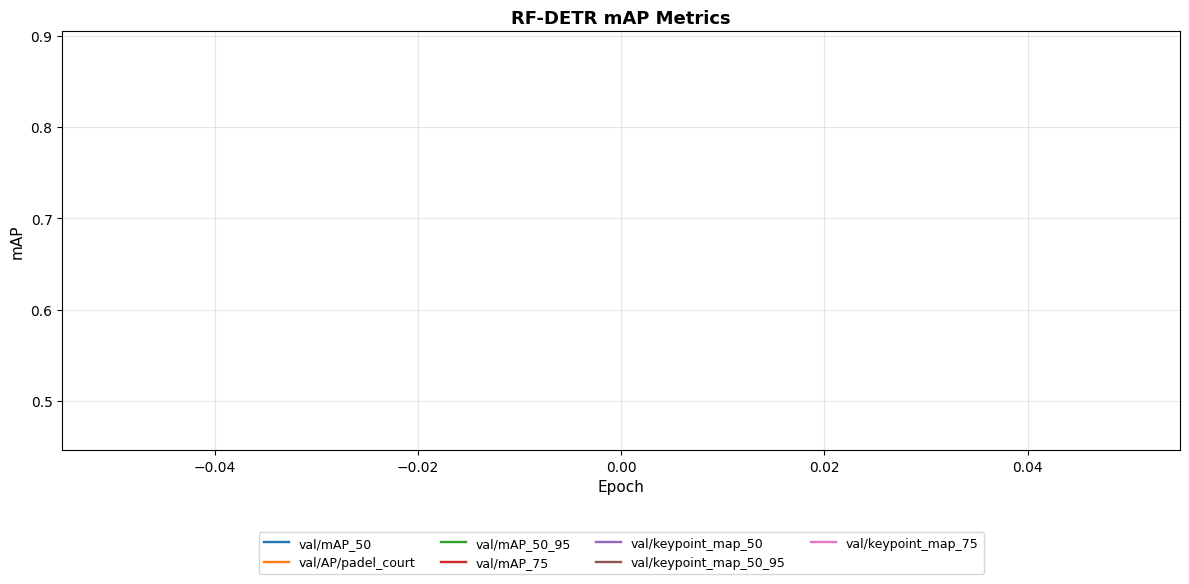

In [79]:
map_figure = plot_map_metrics(str(METRICS_CSV))
display(map_figure)
plt.close(map_figure)

### Load checkpoint and run inference

`from_checkpoint` loads weights from the `.pth` file. For fine-tuned keypoint models, also pass `num_keypoints_per_class` and `num_classes` from the training schema above. Otherwise the model falls back to the COCO default (17 keypoints) and predictions will be wrong.

In [82]:
loaded_model = RFDETRKeypointPreview.from_checkpoint(
    "/content/drive/MyDrive/project/RFDETR/output/keypoint_basketball_court_detection_demo/checkpoint_best_regular.pth",
    device="cuda",
    num_classes=NUM_CLASSES,
    num_keypoints_per_class=NUM_KEYPOINTS_PER_CLASS,
)

[2026-08-03 11:44:59] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-03 11:44:59] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-08-03 11:45:00] [WARNING] rf-detr - load_pretrain_weights: checkpoint lacks args.num_queries / args.group_detr; falling back to flat slice. With group_detr=13 this may scramble per-group query structure if the checkpoint was trained with group_detr > 1.


### sample Images for Inference

In [83]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

def list_images_in_directory(directory: Path) -> list[Path]:
    if not directory.is_dir():
        return []
    return sorted(
        path for path in directory.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )

inference_image_paths = list_images_in_directory(DATASET_DIR / "test")
if not inference_image_paths:
    inference_image_paths = list_images_in_directory(DATASET_DIR / "valid")
if not inference_image_paths:
    inference_image_paths = list_images_in_directory(DATASET_DIR / "train")
if not inference_image_paths:
    raise FileNotFoundError(
        f"No images ({', '.join(sorted(IMAGE_EXTENSIONS))}) found under {DATASET_DIR}"
    )


random_generator = random.Random(SEED)

num_images = min(len(inference_image_paths), INFERENCE_IMAGE_COUNT)

inference_image_paths = random_generator.sample(
    inference_image_paths,
    num_images
)

print(f"Selected {len(inference_image_paths)} inference images")
print(f"inference_images={[str(path) for path in inference_image_paths]}")

Selected 4 inference images
inference_images=['/content/F112-Padel-Keypoints-KP-10/test/mpv-shot0150_jpg.rf.2871ea29746b9014b073f94604a0bdd0.jpg', '/content/F112-Padel-Keypoints-KP-10/test/best-25-so-far_0026_jpg.rf.36876a6d2b394709915e02e0d8902f4e.jpg', '/content/F112-Padel-Keypoints-KP-10/test/best-25-so-far_0486_jpg.rf.4461b3d82b352b6c8583be1645fc63e2.jpg', '/content/F112-Padel-Keypoints-KP-10/test/mpv-shot0181_jpg.rf.fddacf2eebc261d74084fcae65b30a2f.jpg']


### Visualize fine-tuned inference

Nine eval images are sampled at random (seeded by `SEED`) and shown in a 3x3 grid without filenames.

Two thresholds control what you see: `INFERENCE_THRESHOLD` filters detections by bounding-box confidence, and `KEYPOINT_THRESHOLD` hides individual keypoints whose findable confidence is too low.

[2026-08-03 11:45:07] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. For full GPU throughput (e.g. ~8x on T4 via FP16 Tensor Cores), call model.inference(dtype=torch.float16).


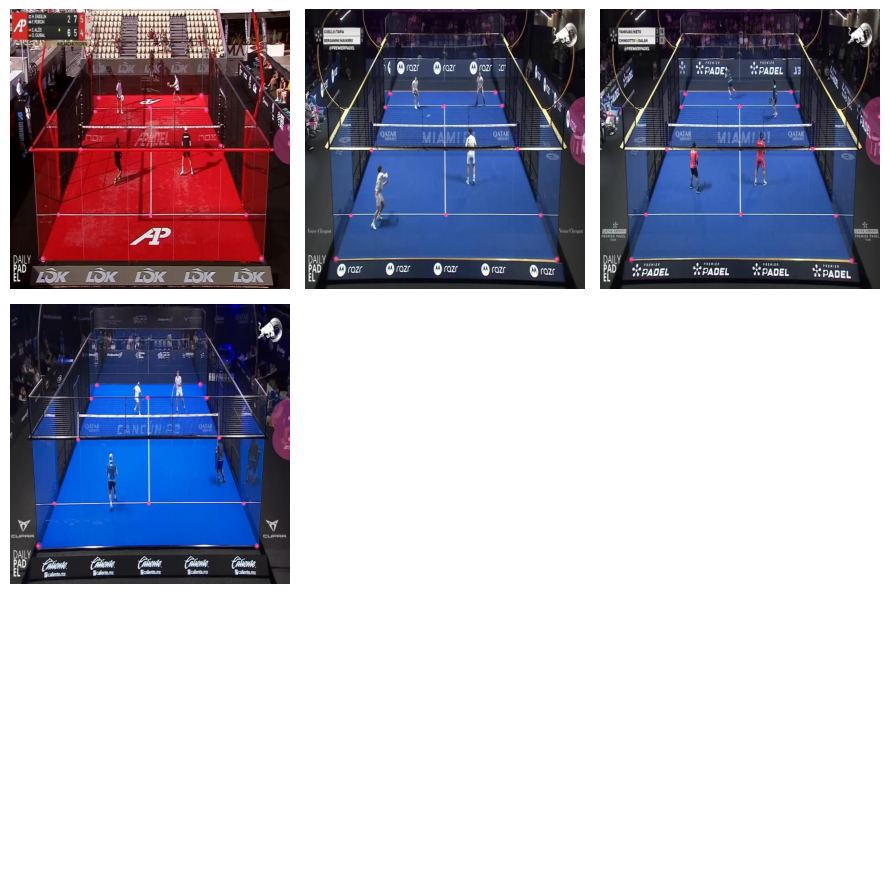

In [84]:
import supervision as sv

def annotate_keypoint_scene(
    scene: np.ndarray, key_points: sv.KeyPoints
) -> np.ndarray:
    result = scene.copy()
    if DRAW_UNCERTAINTY_ELLIPSES and "covariance" in key_points.data:
        result = sv.VertexEllipseAnnotator(
            sigma=ELLIPSE_SIGMA,
            color=sv.Color.ROBOFLOW,
            max_axis=MAX_ELLIPSE_RADIUS,
        ).annotate(scene=result, key_points=key_points)
    return sv.VertexAnnotator(radius=3).annotate(scene=result, key_points=key_points)


inference_results = []
for image_path in inference_image_paths:
    with Image.open(image_path) as opened_image:
        opened_image = opened_image.convert("RGB")
        key_points_raw = loaded_model.predict(
            opened_image, threshold=INFERENCE_THRESHOLD
        )

    key_points_display = _key_points_for_display(
        key_points_raw, keypoint_threshold=KEYPOINT_THRESHOLD
    )
    inference_results.append(
        (np.array(opened_image), key_points_display)
    )

if inference_results:
    figure, axes = plt.subplots(
        INFERENCE_GRID_ROWS,
        INFERENCE_GRID_COLS,
        figsize=(3 * INFERENCE_GRID_COLS, 3 * INFERENCE_GRID_ROWS),
    )
    axes_flat = np.asarray(axes, dtype=object).reshape(-1)

    for axis in axes_flat:
        axis.axis("off")

    for axis, (image_array, key_points) in zip(axes_flat, inference_results):
        axis.imshow(annotate_keypoint_scene(image_array, key_points))

    figure.tight_layout()
    display(figure)
    plt.close(figure)